# Cross-Recording Corroboration & State Capture Analysis

**Author:** Niko Gamulin, PhD | **Date:** March 2026 | **License:** MIT

## Beyond Signal Analysis

Signal-level authentication and ENF dating address **technical authenticity**. The strongest evidence comes from **content corroboration**: do independent speakers, recorded separately, describe the same mechanisms?

Topics mentioned by 3+ independent speakers are extremely difficult to fabricate across uncoordinated individuals.

### Methodology

1. All 14 recordings transcribed (OpenAI Whisper API, manual verification of key quotes)
2. 10 topic groups identified through systematic content coding
3. Corroboration counted per topic: number of independent speakers
4. Relational mapping: who mentions whom across recordings


In [1]:
import sys
sys.path.insert(0, '.')
from style import apply_style, COLORS, PALETTE
apply_style()

import numpy as np
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, FancyArrowPatch
from IPython.display import Image, display
import io, os

FIGURE_DIR = '../figures/corroboration/'
os.makedirs(FIGURE_DIR, exist_ok=True)

with open('../data/metadata.json') as f:
    meta = json.load(f)

speakers = meta['speakers']
print(f"Recordings: {len(meta['recordings'])} | Speakers: {len(speakers)}")
for name, info in speakers.items():
    print(f"  {name} ({info['role']}): {len(info['recordings'])} recordings")


Recordings: 14 | Speakers: 7
  Dominika Svarc Pipan (Former Minister of Justice): 3 recordings
  Nina Zidar Klemencic (Senior Judicial Official): 2 recordings
  Vesna Vukovic (Journalist / Media Figure): 2 recordings
  Rok Hodej (Political Operative): 2 recordings
  Dejan Paravan (Business Figure): 1 recordings
  Tomislav Vukmanovic (Business Figure): 1 recordings
  Joze Oberstar (Former DARS Executive): 3 recordings


  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Eight State Capture Mechanisms

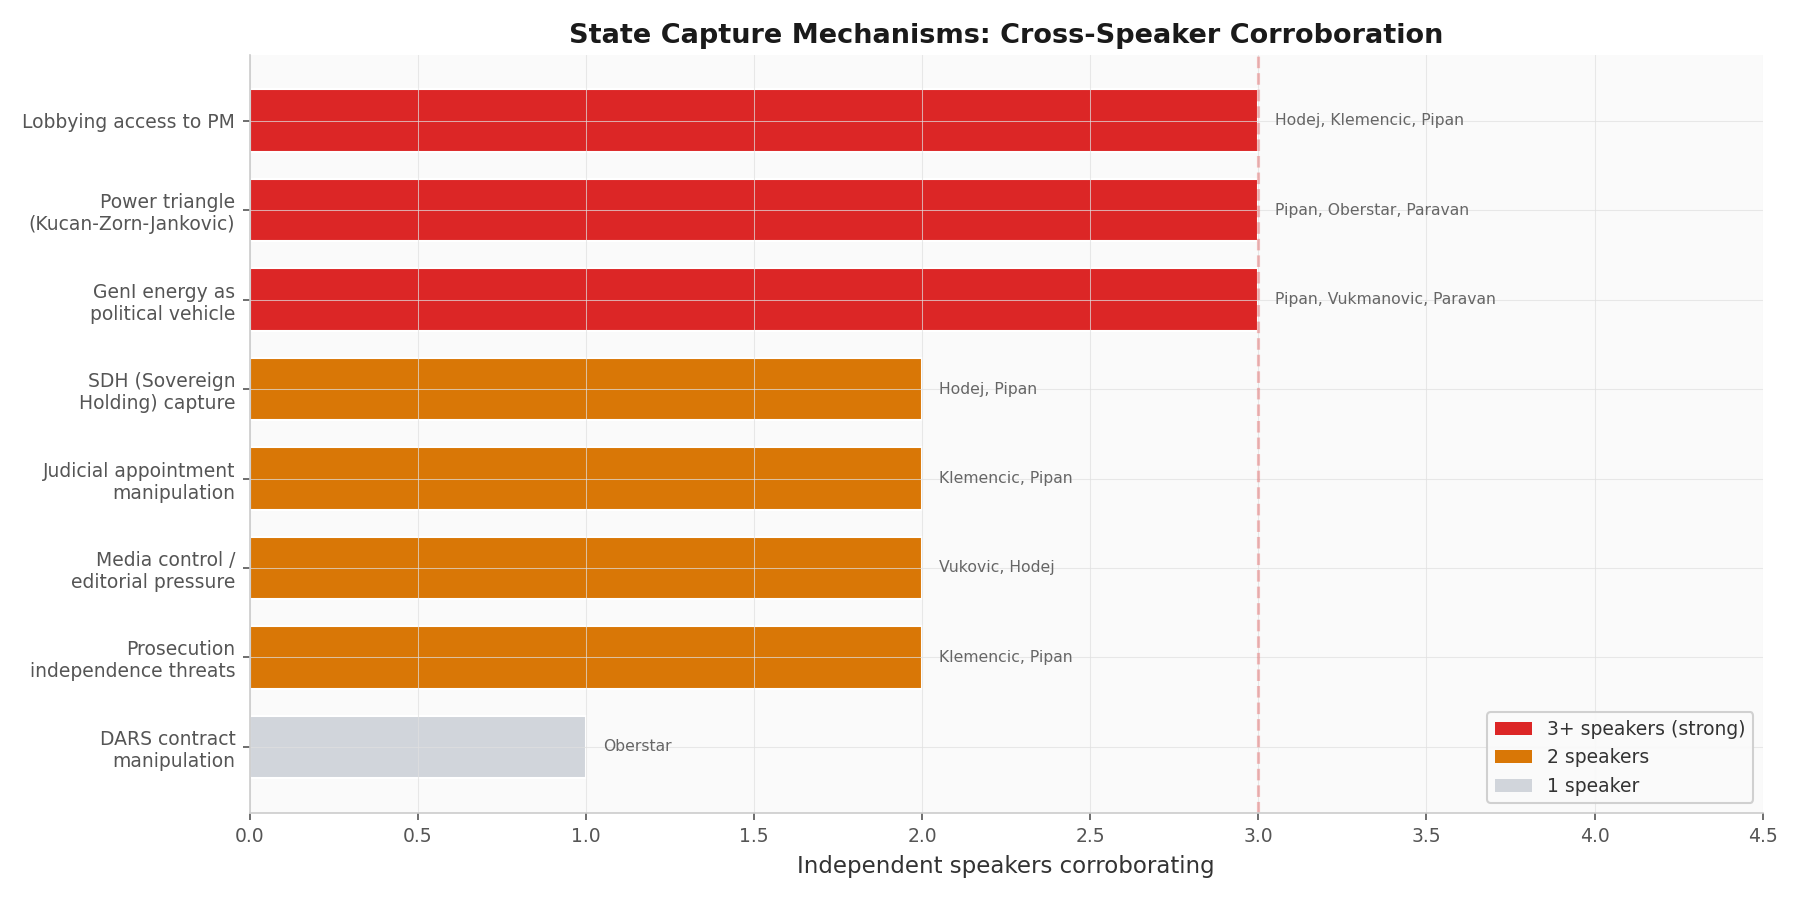

In [2]:
mechanisms = [
    {"name": "Lobbying access to PM", "speakers": ["Rok Hodej", "Nina Zidar Klemencic", "Dominika Svarc Pipan"], "corr": 3},
    {"name": "Power triangle\n(Kucan-Zorn-Jankovic)", "speakers": ["Dominika Svarc Pipan", "Joze Oberstar", "Dejan Paravan"], "corr": 3},
    {"name": "GenI energy as\npolitical vehicle", "speakers": ["Dominika Svarc Pipan", "Tomislav Vukmanovic", "Dejan Paravan"], "corr": 3},
    {"name": "SDH (Sovereign\nHolding) capture", "speakers": ["Rok Hodej", "Dominika Svarc Pipan"], "corr": 2},
    {"name": "Judicial appointment\nmanipulation", "speakers": ["Nina Zidar Klemencic", "Dominika Svarc Pipan"], "corr": 2},
    {"name": "DARS contract\nmanipulation", "speakers": ["Joze Oberstar"], "corr": 1},
    {"name": "Media control /\neditorial pressure", "speakers": ["Vesna Vukovic", "Rok Hodej"], "corr": 2},
    {"name": "Prosecution\nindependence threats", "speakers": ["Nina Zidar Klemencic", "Dominika Svarc Pipan"], "corr": 2},
]
mechanisms.sort(key=lambda x: x['corr'], reverse=True)

fig, ax = plt.subplots(figsize=(12, 6))

names = [m['name'] for m in mechanisms]
corrs = [m['corr'] for m in mechanisms]
colors = [COLORS['secondary'] if c >= 3 else COLORS['warning'] if c >= 2 else COLORS['light_gray'] for c in corrs]

bars = ax.barh(range(len(names)), corrs, color=colors, edgecolor='white', height=0.7)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('Independent speakers corroborating', fontsize=11)
ax.set_title('State Capture Mechanisms: Cross-Speaker Corroboration', fontsize=13)
ax.axvline(3, color=COLORS['secondary'], linestyle='--', alpha=0.3)

# Add speaker names on bars
for i, m in enumerate(mechanisms):
    speaker_str = ', '.join([s.split()[-1] for s in m['speakers']])
    ax.text(m['corr'] + 0.05, i, speaker_str, va='center', fontsize=7.5, color='#666666')

ax.set_xlim(0, max(corrs) + 1.5)
ax.invert_yaxis()

legend_els = [Patch(facecolor=COLORS['secondary'], label='3+ speakers (strong)'),
              Patch(facecolor=COLORS['warning'], label='2 speakers'),
              Patch(facecolor=COLORS['light_gray'], label='1 speaker')]
ax.legend(handles=legend_els, loc='lower right', fontsize=9)

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150)
fig.savefig(os.path.join(FIGURE_DIR, 'corroboration_chart.png'), dpi=150)
plt.close()
display(Image(data=buf.getvalue()))


## Topic-Speaker Matrix

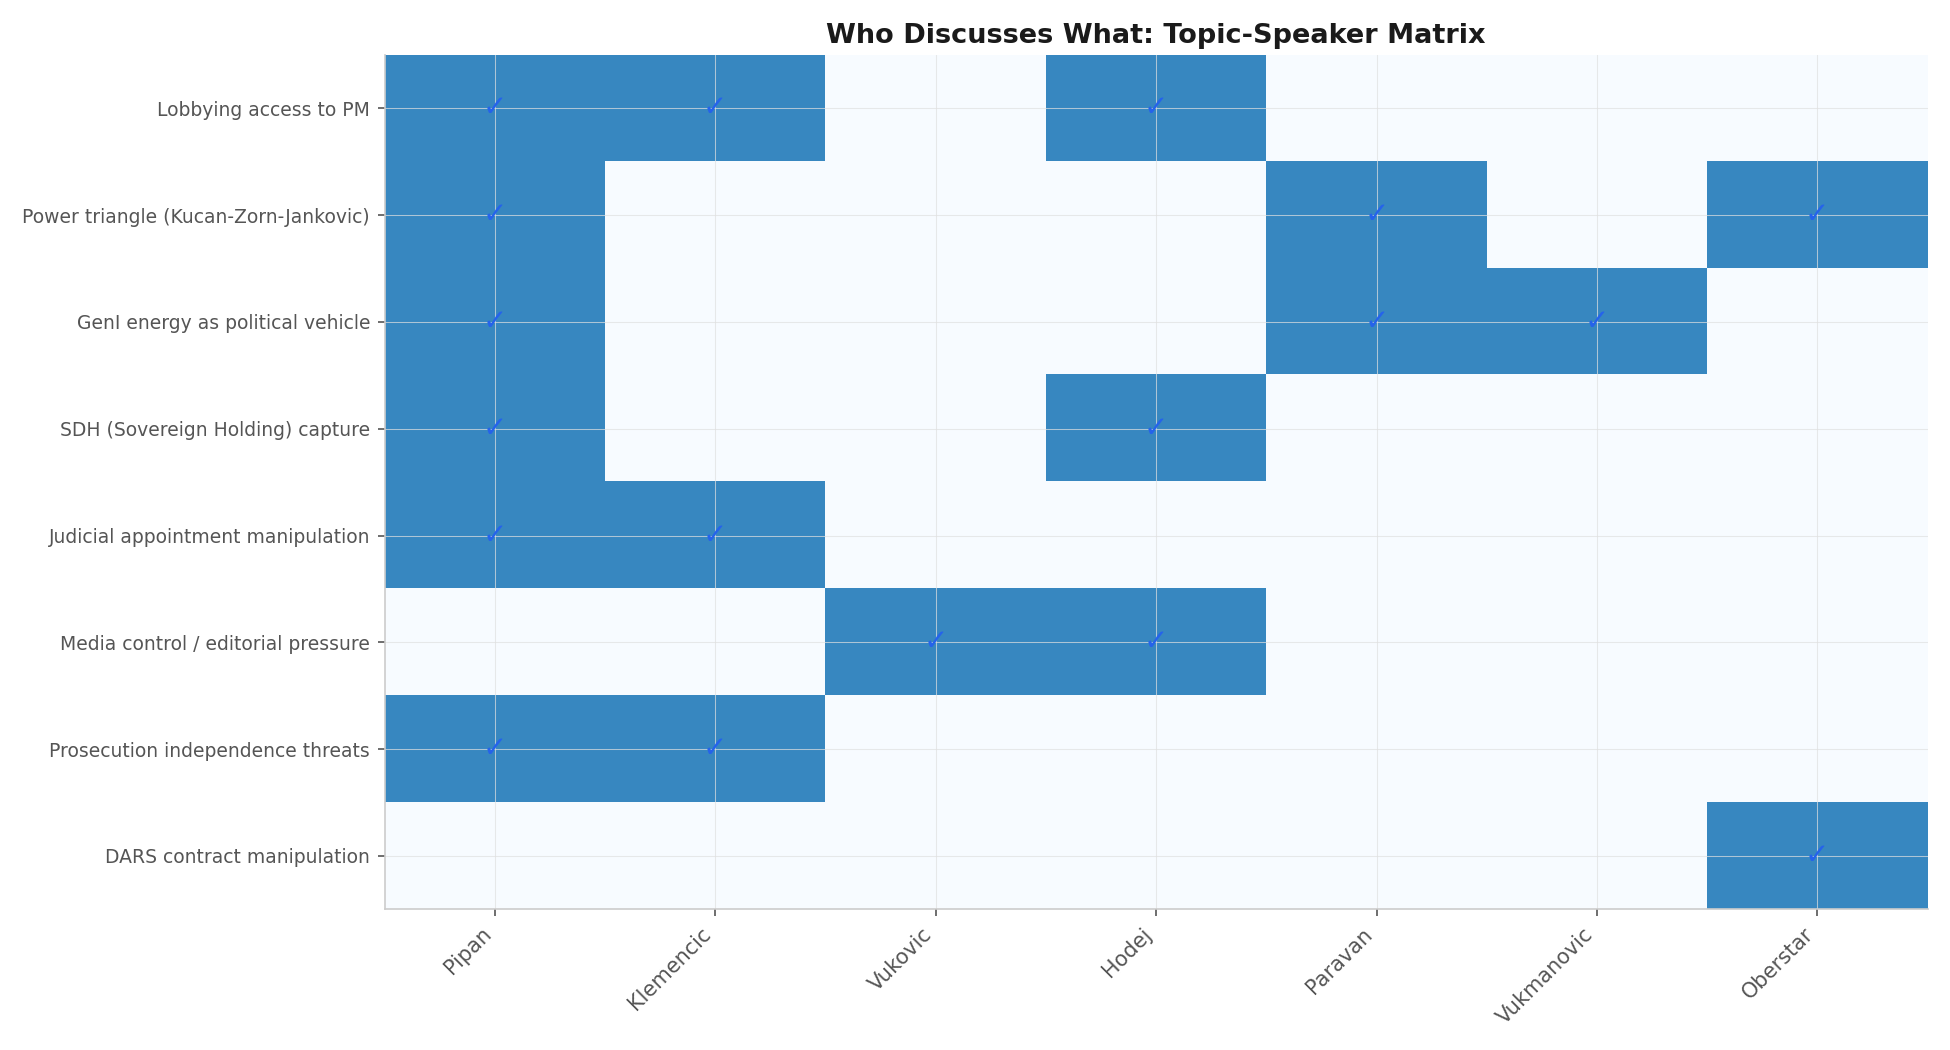

In [3]:
# Heatmap
all_speakers = list(speakers.keys())
topic_names_clean = [m['name'].replace('\n', ' ') for m in mechanisms]

matrix = np.zeros((len(mechanisms), len(all_speakers)))
for i, m in enumerate(mechanisms):
    for j, s in enumerate(all_speakers):
        if s in m['speakers']:
            matrix[i, j] = 1

fig, ax = plt.subplots(figsize=(13, 7))
im = ax.imshow(matrix, cmap='Blues', aspect='auto', vmin=0, vmax=1.5)

ax.set_xticks(range(len(all_speakers)))
ax.set_xticklabels([s.split()[-1] for s in all_speakers], rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(topic_names_clean)))
ax.set_yticklabels(topic_names_clean, fontsize=9)
ax.set_title('Who Discusses What: Topic-Speaker Matrix', fontsize=13)

for i in range(len(topic_names_clean)):
    for j in range(len(all_speakers)):
        if matrix[i, j] > 0:
            ax.text(j, i, '\u2713', ha='center', va='center', fontsize=14, fontweight='bold', color=COLORS['primary'])

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150)
fig.savefig(os.path.join(FIGURE_DIR, 'topic_speaker_matrix.png'), dpi=150)
plt.close()
display(Image(data=buf.getvalue()))


## Relational Graph: Who Mentions Whom

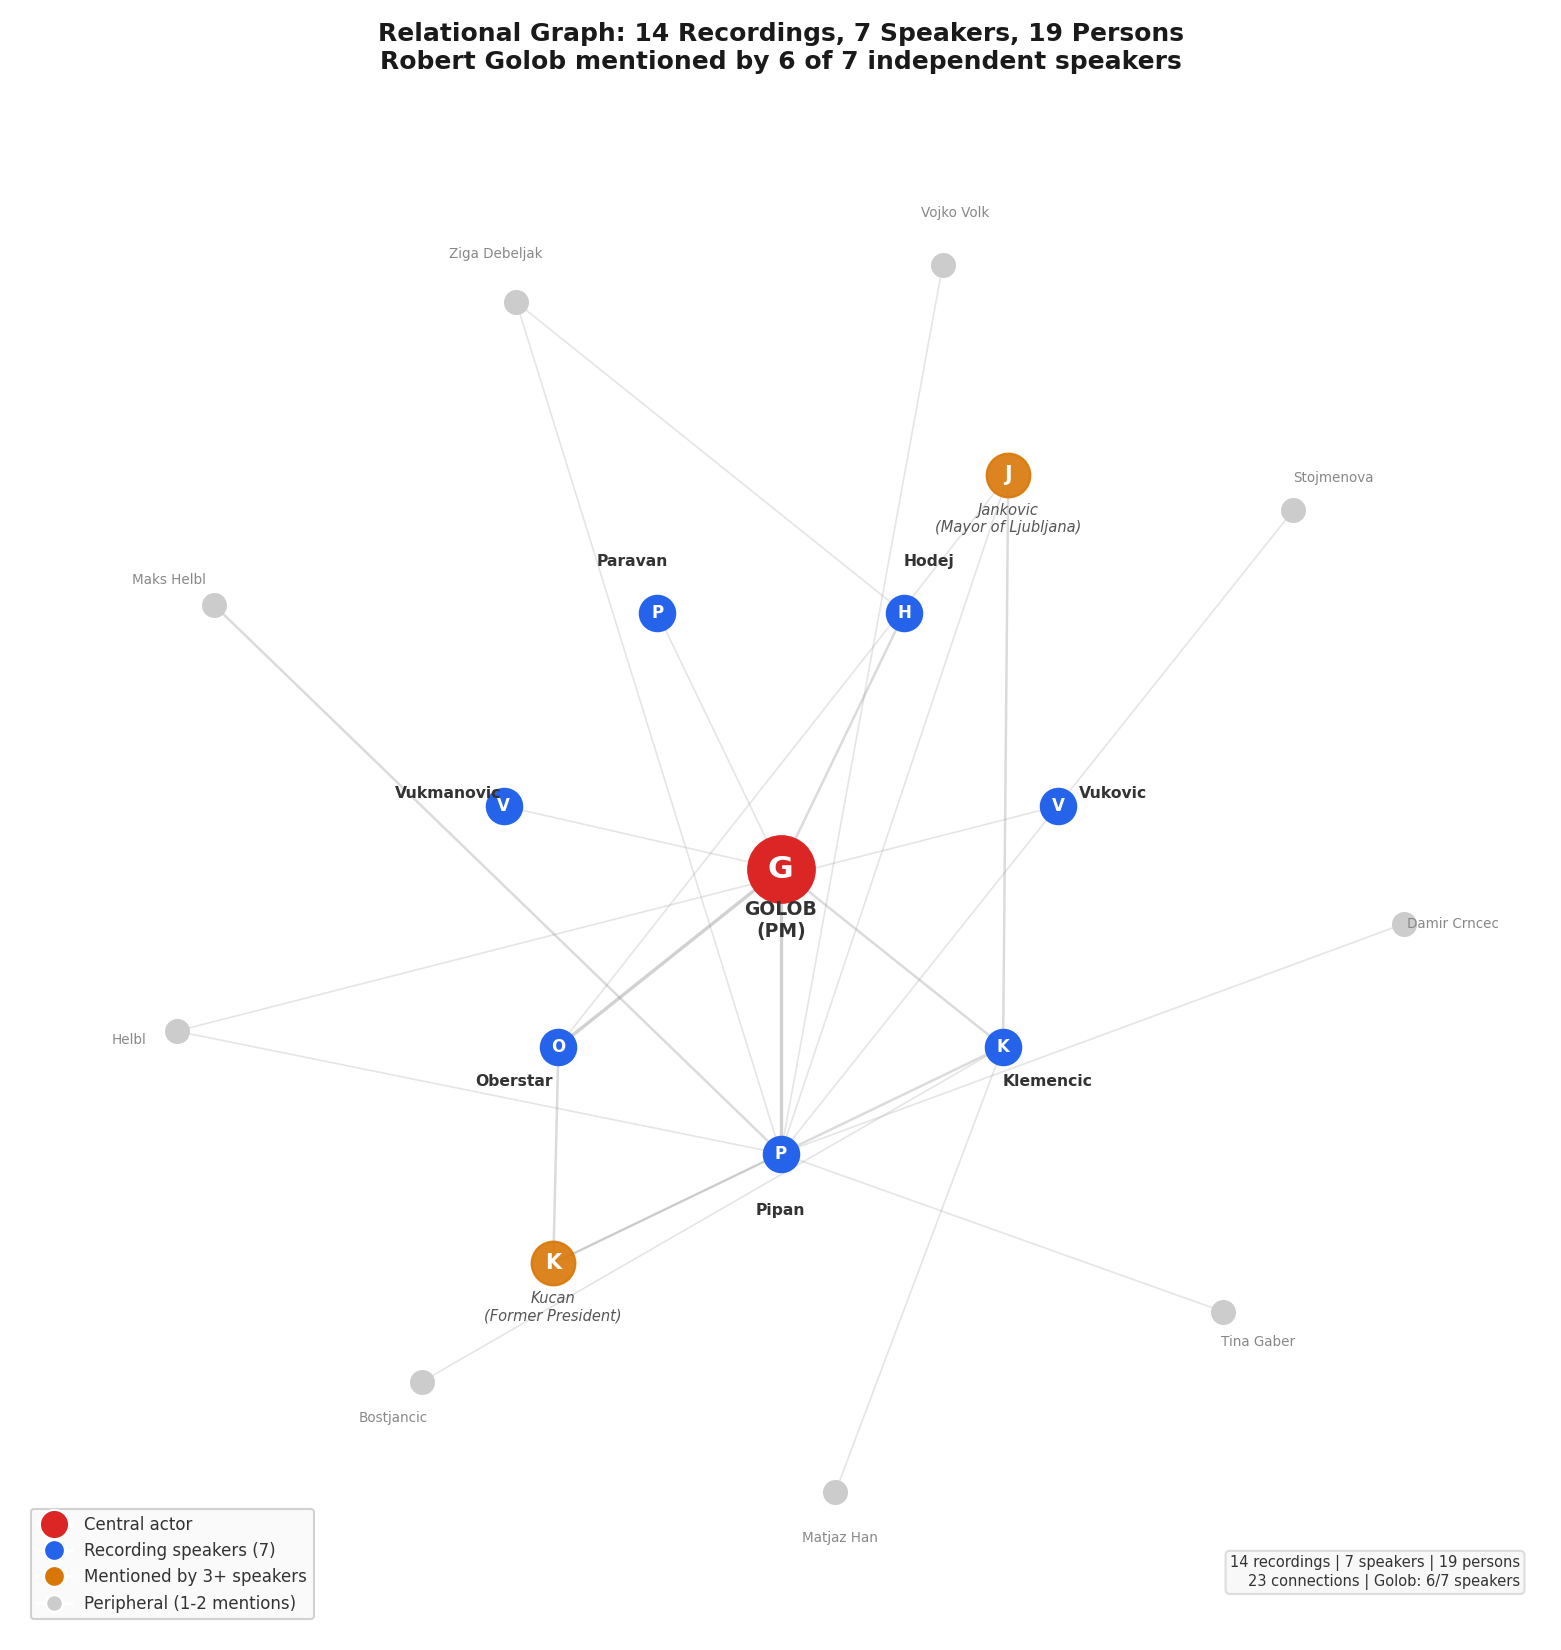

In [4]:
# === Relational Graph ===
# Based on Slovenian original (18 nodes, 20 links) + Oberstar (14 recordings)
# Every edge is explicit — no surname matching bugs

fig, ax = plt.subplots(figsize=(14, 11))
ax.set_xlim(-2.0, 2.0); ax.set_ylim(-2.0, 2.0)
ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

# === NODE DEFINITIONS ===
# Matching Slovenian graph exactly + Oberstar

central = {"Robert Golob": {"role": "PM"}}

speaker_list = [
    "Dominika Svarc Pipan",   # SP01, SP02, SP03
    "Nina Zidar Klemencic",   # NZK01, NZK02
    "Vesna Vukovic",          # VV01, VV02
    "Rok Hodej",              # RH01, RH02
    "Dejan Paravan",          # DP01
    "Tomislav Vukmanovic",    # TV01
    "Joze Oberstar",          # JO01, JO02, JO03 (added for 14-recording version)
]

major_mentioned = {
    "Zoran Jankovic": "Mayor of Ljubljana",
    "Milan Kucan": "Former President",
}

peripheral_nodes = {
    "Tina Gaber": "First Lady",
    "Damir Crncec": "Fmr State Sec Defense",
    "Emilija Stojmenova": "Fmr Min Digital",
    "Vojko Volk": "State Sec Security",
    "Ziga Debeljak": "SDH Board President",
    "Maks Helbl": "GEN-I Board",
    "Barbara Kolenko Helbl": "Sec Gen Government",
    "Klemen Bostjancic": "Finance Minister",
    "Matjaz Han": "Economy Minister",
}

# === EXPLICIT EDGES (Slovenian 20 + Oberstar 3) ===
edges = [
    # Svarc Pipan connections (10 links in SLO graph)
    ("Dominika Svarc Pipan", "Robert Golob", 3),
    ("Dominika Svarc Pipan", "Tina Gaber", 1),
    ("Dominika Svarc Pipan", "Damir Crncec", 1),
    ("Dominika Svarc Pipan", "Emilija Stojmenova", 1),
    ("Dominika Svarc Pipan", "Vojko Volk", 1),
    ("Dominika Svarc Pipan", "Ziga Debeljak", 1),
    ("Dominika Svarc Pipan", "Maks Helbl", 2),
    ("Dominika Svarc Pipan", "Barbara Kolenko Helbl", 1),
    ("Dominika Svarc Pipan", "Zoran Jankovic", 1),
    ("Dominika Svarc Pipan", "Milan Kucan", 1),
    # Zidar Klemencic connections (5 links)
    ("Nina Zidar Klemencic", "Robert Golob", 2),
    ("Nina Zidar Klemencic", "Klemen Bostjancic", 1),
    ("Nina Zidar Klemencic", "Matjaz Han", 1),
    ("Nina Zidar Klemencic", "Milan Kucan", 2),
    ("Nina Zidar Klemencic", "Zoran Jankovic", 2),
    # Vukovic connections (1 link — NOT connected to Golob in SLO graph)
    ("Vesna Vukovic", "Barbara Kolenko Helbl", 1),
    # Hodej connections (2 links)
    ("Rok Hodej", "Robert Golob", 2),
    ("Rok Hodej", "Ziga Debeljak", 1),
    # Paravan connections (1 link)
    ("Dejan Paravan", "Robert Golob", 1),
    # Vukmanovic connections (1 link)
    ("Tomislav Vukmanovic", "Robert Golob", 1),
    # === NEW: Oberstar connections (from JO01, JO02, JO03) ===
    ("Joze Oberstar", "Robert Golob", 3),
    ("Joze Oberstar", "Milan Kucan", 2),
    ("Joze Oberstar", "Zoran Jankovic", 1),
]

n_total = 1 + len(speaker_list) + len(major_mentioned) + len(peripheral_nodes)

ax.set_title(f'Relational Graph: 14 Recordings, {len(speaker_list)} Speakers, {n_total} Persons\n'
             f'Robert Golob mentioned by 6 of 7 independent speakers',
             fontsize=12, fontweight='bold', pad=20)

# === POSITION LAYOUT ===
positions = {}

# Center: Golob
positions["Robert Golob"] = (0, 0)

# Inner ring: speakers
for i, name in enumerate(speaker_list):
    angle = 2 * np.pi * i / len(speaker_list) - np.pi/2
    positions[name] = (0.75 * np.cos(angle), 0.75 * np.sin(angle))

# Mid ring: major mentioned
major_names = list(major_mentioned.keys())
for i, name in enumerate(major_names):
    angle = np.pi/3 + i * np.pi  # opposite sides
    positions[name] = (1.2 * np.cos(angle), 1.2 * np.sin(angle))

# Outer ring: peripheral
periph_names = list(peripheral_nodes.keys())
for i, name in enumerate(periph_names):
    angle = 2 * np.pi * i / len(periph_names) - np.pi/4
    positions[name] = (1.65 * np.cos(angle), 1.65 * np.sin(angle))

# === DRAW EDGES FIRST (zorder=1) ===
for src, tgt, weight in edges:
    if src in positions and tgt in positions:
        x1, y1 = positions[src]
        x2, y2 = positions[tgt]
        lw = 0.4 + 0.4 * weight
        alpha = 0.15 + 0.1 * weight
        ax.plot([x1, x2], [y1, y2], '-', color='#999999', lw=lw, alpha=alpha, zorder=1)

# === DRAW NODES ===

# Golob (central)
gx, gy = positions["Robert Golob"]
ax.plot(gx, gy, 'o', markersize=32, color=COLORS['secondary'], zorder=5)
ax.text(gx, gy, 'G', ha='center', va='center', fontsize=15, color='white', fontweight='bold', zorder=6)
ax.annotate('GOLOB\n(PM)', (gx, gy - 0.18), ha='center', fontsize=9, fontweight='bold', color='#333333', zorder=6)

# Speakers (blue)
for name in speaker_list:
    x, y = positions[name]
    short = name.split()[-1]
    ax.plot(x, y, 'o', markersize=17, color=COLORS['primary'], zorder=5)
    ax.text(x, y, short[0], ha='center', va='center', fontsize=8, color='white', fontweight='bold', zorder=6)
    label_angle = np.arctan2(y, x)
    lx = x + 0.15 * np.cos(label_angle)
    ly = y + 0.15 * np.sin(label_angle)
    ax.annotate(short, (lx, ly), ha='center', va='center', fontsize=7.5, fontweight='bold', color='#333333', zorder=6)

# Major mentioned (orange)
for name, role in major_mentioned.items():
    x, y = positions[name]
    short = name.split()[-1]
    ax.plot(x, y, 'o', markersize=21, color=COLORS['warning'], alpha=0.9, zorder=5)
    ax.text(x, y, short[0], ha='center', va='center', fontsize=10, color='white', fontweight='bold', zorder=6)
    ax.annotate(f'{short}\n({role})', (x, y - 0.15), ha='center', fontsize=7, style='italic', color='#555555', zorder=6)

# Peripheral (gray)
for name, role in peripheral_nodes.items():
    x, y = positions[name]
    ax.plot(x, y, 'o', markersize=11, color='#cccccc', zorder=5)
    # Label outside
    label_angle = np.arctan2(y, x)
    lx = x + 0.13 * np.cos(label_angle)
    ly = y + 0.13 * np.sin(label_angle)
    ax.annotate(name.split()[-1] if len(name) > 15 else name, (lx, ly),
                ha='center', fontsize=6.5, color='#888888', zorder=6)

# === LEGEND ===
legend_els = [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS['secondary'], markersize=14, label='Central actor'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS['primary'], markersize=10, label=f'Recording speakers ({len(speaker_list)})'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS['warning'], markersize=10, label='Mentioned by 3+ speakers'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#cccccc', markersize=8, label='Peripheral (1-2 mentions)'),
]
ax.legend(handles=legend_els, loc='lower left', fontsize=8, framealpha=0.9)

# === STATS BOX ===
n_golob_speakers = sum(1 for s,t,w in edges if t == "Robert Golob" and s != "Vesna Vukovic")
stats_text = f"14 recordings | {len(speaker_list)} speakers | {n_total} persons\n{len(edges)} connections | Golob: {n_golob_speakers}/7 speakers"
ax.text(1.95, -1.9, stats_text, fontsize=7, ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f8f8f8', edgecolor='#dddddd'))

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150)
fig.savefig(os.path.join(FIGURE_DIR, 'relational_graph_en.png'), dpi=150)
plt.close()
display(Image(data=buf.getvalue()))


## Why Corroboration Matters More Than Signal Analysis

To fabricate this level of cross-speaker consistency, one would need to:
1. Record 7 different people separately
2. Coordinate their narratives to mention the same names, mechanisms, and events
3. Ensure temporal and factual consistency across all recordings
4. Do this without any of the 7 speakers revealing the coordination

This is functionally implausible. The corroboration matrix is stronger evidence than any signal-level test.

### Limitations
- Automated transcription (Whisper API) with manual spot-checks -- errors possible
- Topic coding is subjective
- Corroboration does not prove described mechanisms are illegal -- courts decide that
- Speakers may share common knowledge without independent observation
